In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
praveengovi_emotions_dataset_for_nlp_path = kagglehub.dataset_download('praveengovi/emotions-dataset-for-nlp')

print('Data source import complete.')


Data source import complete.


# **1. Import Libraries**

In [ ]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 798.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.1 MB/s eta 0:00:00


In [ ]:
# ==============================
# Basic Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ==============================
# NLTK: Natural Language Toolkit
# ==============================
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import CFG
from collections import Counter

# ==============================
# Text Preprocessing & Utilities
# ==============================
import re
import random

# ==============================
# Machine Learning & Evaluation
# ==============================
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ==============================
# Streamlit for Web App
# ==============================
import streamlit as st

# ==============================
# Configuration
# ==============================
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [ ]:
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

# **2. Read Data**

In [ ]:
train_df=pd.read_csv("/kaggle/input/emotions-dataset-for-nlp/train.txt",sep=";",
    header=None,
    names=["text", "emotion"])
train_df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [ ]:
test_df=pd.read_csv("/kaggle/input/emotions-dataset-for-nlp/test.txt",sep=";",header=None,names=["text", "emotion"])
test_df.head()

,text,emotion
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [ ]:
val_df=pd.read_csv("/kaggle/input/emotions-dataset-for-nlp/val.txt",sep=";",header=None,names=["text", "emotion"])
val_df.head()

,text,emotion
0,im feeling quite sad and sorry for myself but ...,sadness
1,i feel like i am still looking at a blank canv...,sadness
2,i feel like a faithful servant,love
3,i am just feeling cranky and blue,anger
4,i can have for a treat or if i am feeling festive,joy


# **3. Explore Data**

**Preview the Data**

In [ ]:
print("Train shape:",train_df.shape)
print("Test shape:", test_df.shape)
print("Validation shape:", val_df.shape)

Train shape: (16000, 2)
Test shape: (2000, 2)
Validation shape: (2000, 2)


In [ ]:
print("Missing values in train:", train_df.isnull().sum())
print("Missing values in test:", test_df.isnull().sum())
print("Missing values in val:", val_df.isnull().sum())

Missing values in train: text       0
emotion    0
dtype: int64
Missing values in test: text       0
emotion    0
dtype: int64
Missing values in val: text       0
emotion    0
dtype: int64


**Check Class Distribution**

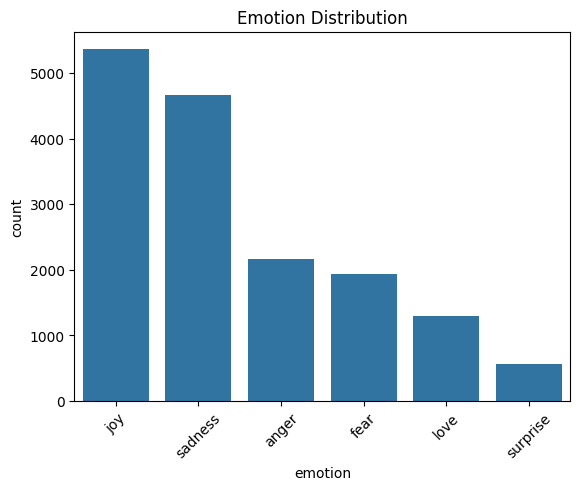

In [ ]:
sns.countplot(x='emotion', data=train_df, order=train_df['emotion'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Emotion Distribution")
plt.show()

**Number of Unique Emotions**

In [ ]:
print("Unique emotions:", train_df["emotion"].nunique())
print("Emotion labels:", train_df["emotion"].unique())

Unique emotions: 6
Emotion labels: ['sadness' 'anger' 'love' 'surprise' 'fear' 'joy']


**Length of Texts**

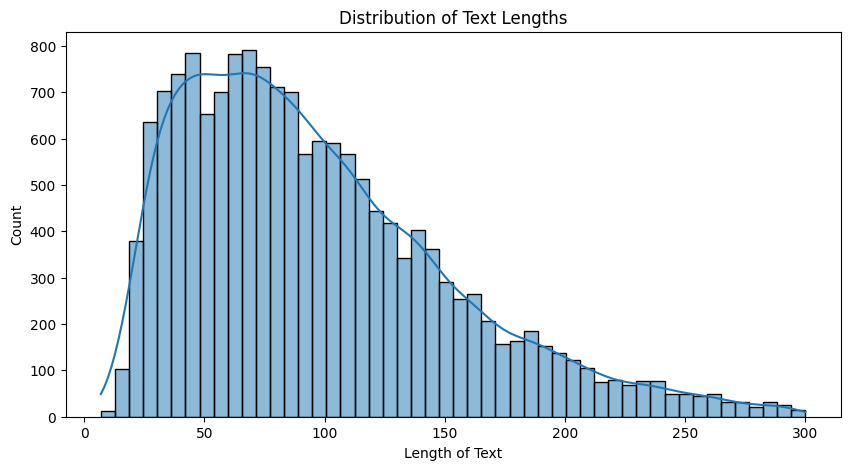

In [ ]:
train_df['text_length'] = train_df['text'].apply(len)

plt.figure(figsize=(10,5))
sns.histplot(train_df['text_length'], bins=50, kde=True)
plt.title("Distribution of Text Lengths")
plt.xlabel("Length of Text")
plt.show()

In [ ]:
print("Duplicates in train:", train_df.duplicated().sum())

Duplicates in train: 1


In [ ]:
train_df.drop_duplicates(inplace=True)

**Common Words (Raw Text)**

In [ ]:
all_words = " ".join(train_df["text"].str.lower()).split()
common = Counter(all_words).most_common(10)
print("Top 10 common words:", common)

Top 10 common words: [('i', 25858), ('feel', 11182), ('and', 9589), ('to', 8971), ('the', 8370), ('a', 6200), ('feeling', 5112), ('that', 5112), ('of', 4990), ('my', 4283)]


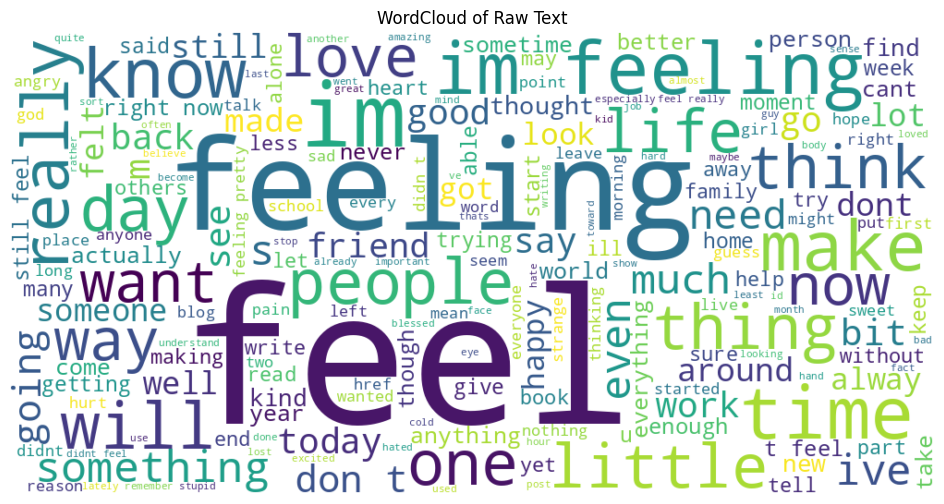

In [ ]:
from wordcloud import WordCloud

text = " ".join(train_df["text"])
wordcloud = WordCloud(width=1000, height=500, background_color="white").generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of Raw Text")
plt.show()


# **3. Text Processing**

In [ ]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
print(stop_words)

{"don't", 'here', 'ourselves', 'we', "we're", 'where', 'don', 'by', 'have', 'shan', 'shouldn', "wouldn't", "they're", 'i', 'is', 'to', "it's", 'under', "we'd", 't', 'my', "you'd", "hadn't", "hasn't", 'below', "won't", 'yourselves', 'can', 'these', 'until', 'they', 'haven', 'on', 'so', 'there', 'mightn', 'theirs', 'same', 'an', 'more', 'when', "she'll", 'weren', 'not', 'such', 'some', "i've", "couldn't", "doesn't", 'm', "mustn't", 'which', 'doing', 'those', 'your', 'a', 'y', 'that', "you'll", 'hasn', 'down', 'ma', 'all', 'up', 'aren', 'few', "you've", 'hadn', 'our', 'themselves', 'between', 'been', 'whom', 'after', "it'll", "i'm", 'how', "should've", 'wasn', 'just', 'off', 'then', "they've", 'why', "i'd", "aren't", 'did', 'each', 'it', 'd', 'having', 'her', 'over', 've', 'doesn', 'am', 'its', 'at', 'being', 'isn', 'from', 'the', 'again', 'no', 'she', "we've", 'wouldn', 'yourself', "mightn't", 'before', 'didn', 'has', 'hers', "shouldn't", "weren't", "needn't", "i'll", 're', 's', 'above',

In [ ]:
# Function to clean and preprocess the text
def clean_text(text):
    # Remove all non-alphabetic characters
    text = re.sub('[^a-zA-Z]', ' ', text)

    # Convert the entire text to lowercase
    text = text.lower()

    # Tokenize the text (split it into individual words)
    tokens = nltk.word_tokenize(text)

    # Remove stopwords and perform lemmatization (reduce words to their base form)
    # filter out words that are too short (less than 3 characters)
    cleaned = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]

    # Join the cleaned tokens back into a single string
    return ' '.join(cleaned)

In [ ]:
train_df['cleaned_text'] = train_df['text'].apply(clean_text)
val_df['cleaned_text'] = val_df['text'].apply(clean_text)
test_df['cleaned_text'] = test_df['text'].apply(clean_text)

In [ ]:
print(train_df[['text', 'cleaned_text']].head())
print('-'*50)
print(val_df[['text', 'cleaned_text']].head())
print('-'*50)
print(test_df[['text', 'cleaned_text']].head())

                                                text  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   

                                        cleaned_text  
0                              didnt feel humiliated  
1  feeling hopeless damned hopeful around someone...  
2             grabbing minute post feel greedy wrong  
3  ever feeling nostalgic fireplace know still pr...  
4                                    feeling grouchy  
--------------------------------------------------
                                                text  \
0  im feeling quite sad and sorry for myself but ...   
1  i feel like i am still looking at a blank canv...   
2                     i feel like a faithful servant   
3                  i am just feeling cranky and blue   
4 

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the vectorizer and fit it on the training data
tfidf = TfidfVectorizer(max_features=5000)
X_train = tfidf.fit_transform(train_df["cleaned_text"])
X_test = tfidf.transform(test_df["cleaned_text"])

# Transform validation and test data
X_val = tfidf.transform(val_df['text'])
X_test = tfidf.transform(test_df['text'])

# Labels
y_train = train_df['emotion']
y_val = val_df['emotion']
y_test = test_df['emotion']

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize model
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Predict on validation data
y_val_pred_lr = lr_model.predict(X_val)

# Evaluation
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_lr))
print("Classification Report:\n", classification_report(y_val, y_val_pred_lr))

Validation Accuracy: 0.878
Classification Report:
               precision    recall  f1-score   support

       anger       0.90      0.84      0.87       275
        fear       0.86      0.78      0.82       212
         joy       0.87      0.95      0.91       704
        love       0.89      0.71      0.79       178
     sadness       0.88      0.94      0.91       550
    surprise       0.89      0.63      0.74        81

    accuracy                           0.88      2000
   macro avg       0.88      0.81      0.84      2000
weighted avg       0.88      0.88      0.88      2000



In [ ]:
# Predict on test data
y_test_pred_lr = lr_model.predict(X_test)

# Evaluation
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred_lr))

Test Accuracy: 0.8715

Classification Report:
               precision    recall  f1-score   support

       anger       0.88      0.85      0.86       275
        fear       0.87      0.80      0.83       224
         joy       0.85      0.95      0.90       695
        love       0.81      0.63      0.71       159
     sadness       0.90      0.92      0.91       581
    surprise       0.89      0.52      0.65        66

    accuracy                           0.87      2000
   macro avg       0.87      0.78      0.81      2000
weighted avg       0.87      0.87      0.87      2000



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predict on validation data
y_val_pred_rf = rf_model.predict(X_val)

# Evaluation
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_rf))
print("Classification Report:\n", classification_report(y_val, y_val_pred_rf))


Validation Accuracy: 0.8905
Classification Report:
               precision    recall  f1-score   support

       anger       0.90      0.88      0.89       275
        fear       0.78      0.90      0.84       212
         joy       0.92      0.91      0.92       704
        love       0.84      0.80      0.82       178
     sadness       0.91      0.91      0.91       550
    surprise       0.86      0.78      0.82        81

    accuracy                           0.89      2000
   macro avg       0.87      0.86      0.87      2000
weighted avg       0.89      0.89      0.89      2000



In [ ]:
# Predict on test data
y_test_pred = rf_model.predict(X_test)

# Evaluation
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

Test Accuracy: 0.8855

Classification Report:
               precision    recall  f1-score   support

       anger       0.89      0.91      0.90       275
        fear       0.84      0.88      0.86       224
         joy       0.91      0.91      0.91       695
        love       0.77      0.74      0.75       159
     sadness       0.94      0.92      0.93       581
    surprise       0.65      0.62      0.64        66

    accuracy                           0.89      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.89      0.89      0.89      2000



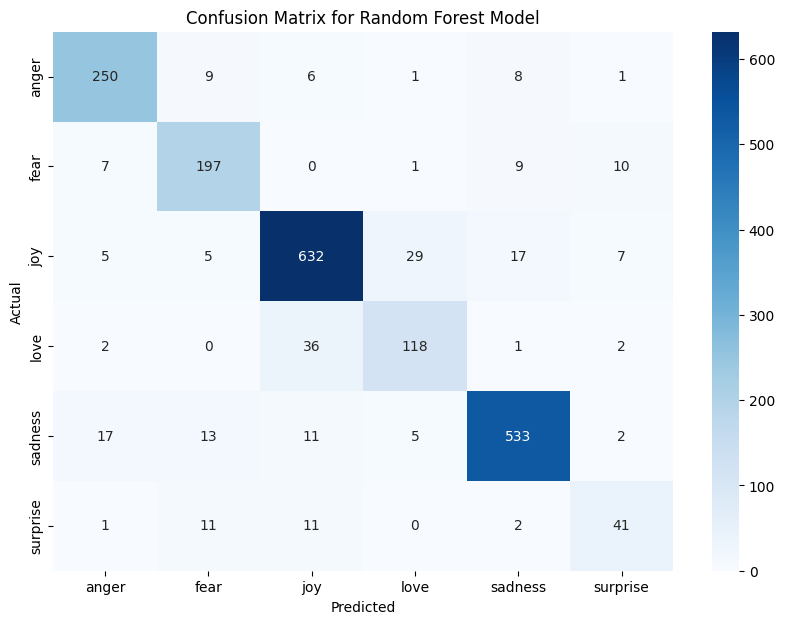

In [ ]:
# Creating the Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plotting the Confusion Matrix using seaborn
plt.figure(figsize=(10,7))  # Set the size of the figure
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
# annot=True: Display the numbers inside the cells, fmt='d': Format as integers, cmap='Blues': Use blue color map
# xticklabels and yticklabels: Label the x and y axes with class names (the emotions)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest Model')
plt.show()

In [ ]:
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
# Predict on validation data
y_val_pred_nb = nb_model.predict(X_val)

# Evaluation
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_nb))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred_nb))

Validation Accuracy: 0.753

Classification Report:
               precision    recall  f1-score   support

       anger       0.95      0.59      0.73       275
        fear       0.92      0.47      0.62       212
         joy       0.72      0.96      0.82       704
        love       0.94      0.18      0.30       178
     sadness       0.71      0.95      0.82       550
    surprise       1.00      0.11      0.20        81

    accuracy                           0.75      2000
   macro avg       0.87      0.54      0.58      2000
weighted avg       0.80      0.75      0.72      2000



In [ ]:
# Predict on test data
y_test_pred_nb = nb_model.predict(X_test)

# Evaluation
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred_nb))

Test Accuracy: 0.7555

Classification Report:
               precision    recall  f1-score   support

       anger       0.93      0.52      0.67       275
        fear       0.87      0.49      0.62       224
         joy       0.72      0.98      0.83       695
        love       0.97      0.21      0.35       159
     sadness       0.74      0.94      0.83       581
    surprise       0.00      0.00      0.00        66

    accuracy                           0.76      2000
   macro avg       0.70      0.52      0.55      2000
weighted avg       0.77      0.76      0.72      2000



In [ ]:
import joblib
joblib.dump(rf_model, 'emotion_detection_model_rf.joblib')

joblib.dump(tfidf, 'tfidf_vectorizer.joblib')

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!


In [ ]:
# Loading the saved model and vectorizer
loaded_rf_model = joblib.load('emotion_detection_model_rf.joblib')
loaded_tfidf = joblib.load('tfidf_vectorizer.joblib')

print("Model and Vectorizer loaded successfully!")

Model and Vectorizer loaded successfully!


In [ ]:
# Example of text input (this could come from a user or a chatbot)
new_text = "I'm really sad and feeling low today."

# Preprocess the text using the loaded vectorizer
new_text_tfidf = loaded_tfidf.transform([new_text])

# Predict the emotion using the loaded model
predicted_emotion = loaded_rf_model.predict(new_text_tfidf)

print(f"The predicted emotion for the input text is: {predicted_emotion[0]}")


The predicted emotion for the input text is: sadness


In [ ]:
# Define a simple CFG grammar for basic emotion-related sentence structures
grammar = CFG.fromstring("""
    S -> NP VP
    NP -> Det N | 'I'
    VP -> V NP | V Adj
    Det -> 'a' | 'an' | 'the'
    N -> 'feeling' | 'emotion' | 'day'
    V -> 'feel' | 'am' | 'is'
    Adj -> 'happy' | 'sad' | 'angry' | 'scared' | 'surprised'
""")

In [ ]:
parser = nltk.ChartParser(grammar)

In [ ]:
# Function to check if input follows CFG structure
def is_valid_emotion_structure(text):
    tokens = text.lower().split()
    try:
        for tree in parser.parse(tokens):
            return True
    except ValueError:
        return False
    return False

In [ ]:
'''# Streamlit Web App
st.title("🧠 Emotion Detection Chatbot")
st.markdown("Enter a sentence to detect the **emotion**.")

user_input = st.text_input("You:")

if user_input:
    if is_valid_emotion_structure(user_input):
        cleaned = clean_text(user_input)
        vec_input = tfidf.transform([cleaned])
        prediction = model.predict(vec_input)[0]
        st.success(f"Predicted Emotion: **{prediction.capitalize()}**")
    else:
        st.warning("⚠️ Unrecognized or unsupported sentence structure. Try something like: 'I feel happy'")
'''

'# Streamlit Web App\nst.title("🧠 Emotion Detection Chatbot")\nst.markdown("Enter a sentence to detect the **emotion**.")\n\nuser_input = st.text_input("You:")\n\nif user_input:\n    if is_valid_emotion_structure(user_input):\n        cleaned = clean_text(user_input)\n        vec_input = tfidf.transform([cleaned])\n        prediction = model.predict(vec_input)[0]\n        st.success(f"Predicted Emotion: **{prediction.capitalize()}**")\n    else:\n        st.warning("⚠️ Unrecognized or unsupported sentence structure. Try something like: \'I feel happy\'")\n'

In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

rf_model = joblib.load('emotion_detection_model_rf.joblib')
tfidf = joblib.load('tfidf_vectorizer.joblib')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    cleaned = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    return ' '.join(cleaned)

st.title("🧠 Emotion Detection Chatbot")
st.markdown("أدخل جملة ليتم التنبؤ بالعاطفة المرتبطة بها.")

user_input = st.text_input("أدخل نصك هنا:")

if user_input:
    cleaned_input = clean_text(user_input)
    vectorized_input = tfidf.transform([cleaned_input])
    prediction = rf_model.predict(vectorized_input)[0]
    st.success(f"العاطفة المتوقعة: **{prediction.capitalize()}**")

Writing app.py


In [ ]:
!pip install pyngrok

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("2wj6lhjx04XBFerHwGDAtnhxpI2_6Ei327FviPiUKdcXdHXT4")

public_url = ngrok.connect(port='5001')
print(f"Streamlit app URL: {public_url}")

!streamlit run app.py &

ERROR:pyngrok.process.ngrok:t=2025-05-06T14:41:06+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2025-05-06T14:41:06+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2025-05-06T14:41:06+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.